In [26]:
import os
import urllib.request
import tarfile
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
%matplotlib inline

In [27]:
DATASET_URL = "http://cogcomp.cs.illinois.edu/Data/Car/CarData.tar.gz"
DATA_DIR = "/content/CarData"
ARCHIVE_NAME = "/content/CarData.tar.gz"
WINDOW_SIZE = (100, 40)
np.random.seed(42)

In [29]:
train_dir = os.path.join(DATA_DIR, "TrainImages")
pos_images = [os.path.join(train_dir, f) for f in os.listdir(train_dir) if f.startswith('pos-')]
neg_images = [os.path.join(train_dir, f) for f in os.listdir(train_dir) if f.startswith('neg-')]

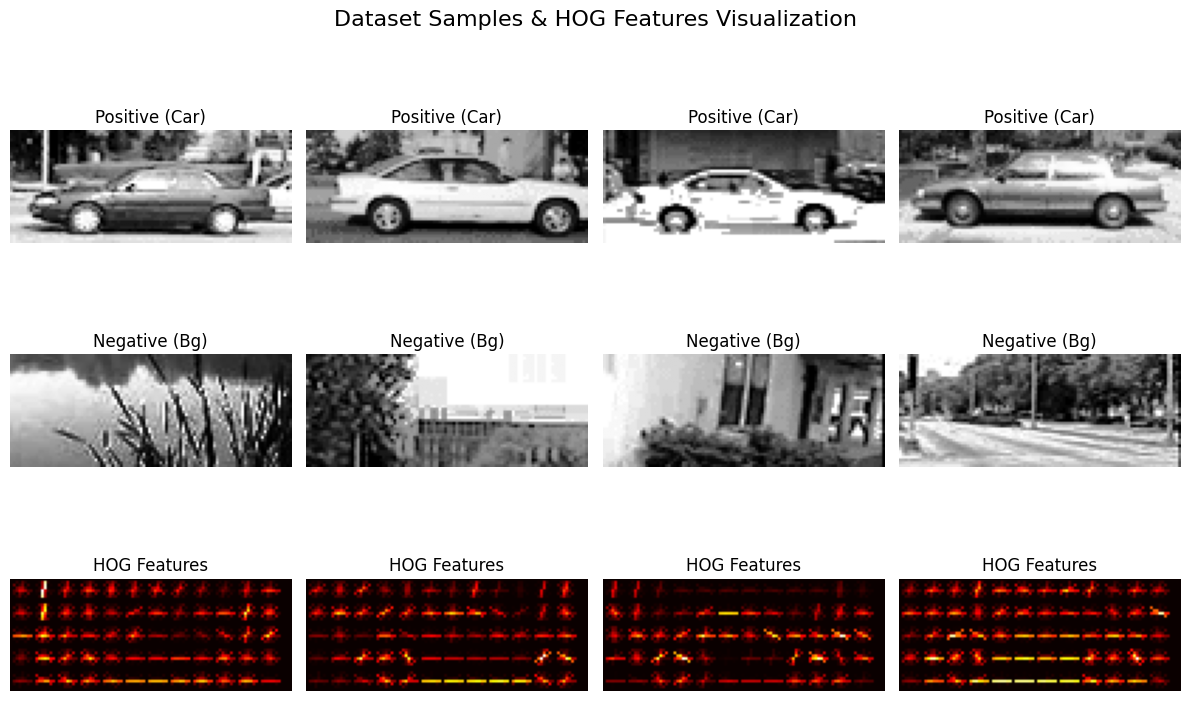

In [30]:
num_samples = 4
fig, axes = plt.subplots(3, num_samples, figsize=(12, 8))
fig.suptitle("Dataset Samples & HOG Features Visualization", fontsize=16)

pos_indices = np.random.choice(len(pos_images), num_samples, replace=False)
neg_indices = np.random.choice(len(neg_images), num_samples, replace=False)

for i in range(num_samples):
    pos_path = pos_images[pos_indices[i]]
    img_pos = cv2.imread(pos_path, cv2.IMREAD_GRAYSCALE)
    if img_pos is not None:
        img_pos_resized = cv2.resize(img_pos, WINDOW_SIZE)
        axes[0, i].imshow(img_pos_resized, cmap='gray')
    axes[0, i].set_title("Positive (Car)")
    axes[0, i].axis('off')

    neg_path = neg_images[neg_indices[i]]
    img_neg = cv2.imread(neg_path, cv2.IMREAD_GRAYSCALE)
    if img_neg is not None:
        img_neg_resized = cv2.resize(img_neg, WINDOW_SIZE)
        axes[1, i].imshow(img_neg_resized, cmap='gray')
    axes[1, i].set_title("Negative (Bg)")
    axes[1, i].axis('off')

    if img_pos is not None:
        _, hog_image = hog(img_pos_resized, orientations=9, pixels_per_cell=(8, 8),
                           cells_per_block=(2, 2), block_norm='L2-Hys', visualize=True, transform_sqrt=True)
        axes[2, i].imshow(hog_image, cmap='hot')
    axes[2, i].set_title("HOG Features")
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

In [32]:
def extract_hog_features(image):
    return hog(image, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2),
               block_norm='L2-Hys', visualize=False, transform_sqrt=True)

print("Extracting HOG features from dataset")
X, y = [], []
for path in pos_images:
    img = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), WINDOW_SIZE)
    X.append(extract_hog_features(img))
    y.append(1)
for path in neg_images:
    img = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), WINDOW_SIZE)
    X.append(extract_hog_features(img))
    y.append(0)

X, y = np.array(X), np.array(y)

model = LinearSVC(max_iter=10000, random_state=42)
model.fit(X, y)
print(f"Training Complete. Accuracy: {model.score(X, y):.4f}")


Extracting HOG features from dataset
Training Complete. Accuracy: 1.0000


In [33]:
def sliding_window(image, step_size, window_size):
    for y in range(0, image.shape[0] - window_size[1] + 1, step_size):
        for x in range(0, image.shape[1] - window_size[0] + 1, step_size):
            yield (x, y, image[y:y + window_size[1], x:x + window_size[0]])

In [34]:
def detect_objects(image, model, window_size, step_size=8, threshold=0.5):
    boxes, scores = [], []
    for (x, y, window) in sliding_window(image, step_size, window_size):
        if window.shape[0] != window_size[1] or window.shape[1] != window_size[0]:
            continue
        features = extract_hog_features(window).reshape(1, -1)
        score = model.decision_function(features)[0]
        if score > threshold:
            boxes.append([x, y, window_size[0], window_size[1]])
            scores.append(float(score))

    indices = cv2.dnn.NMSBoxes(boxes, scores, score_threshold=threshold, nms_threshold=0.3)
    final_boxes = [boxes[i] for i in indices.flatten()] if len(indices) > 0 else []
    print(f"Detected {len(final_boxes)} objects after NMS.")
    return final_boxes

Detected 1 objects after NMS.


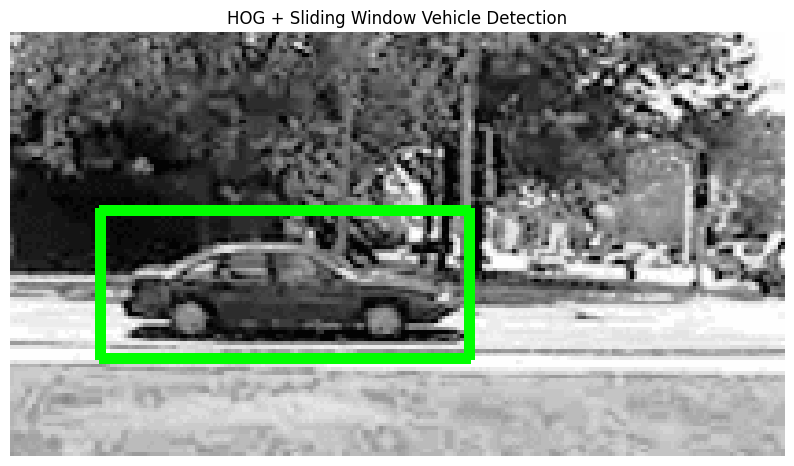

In [35]:
test_image_path = os.path.join(DATA_DIR, "TestImages", "test-0.pgm")
if os.path.exists(test_image_path):
    test_img = cv2.imread(test_image_path, cv2.IMREAD_GRAYSCALE)
    detected_boxes = detect_objects(test_img, model, WINDOW_SIZE, step_size=4, threshold=0.8)

    # Draw boxes and show final result
    img_color = cv2.cvtColor(test_img, cv2.COLOR_GRAY2BGR)
    for (x, y, w, h) in detected_boxes:
        cv2.rectangle(img_color, (x, y), (x + w, y + h), (0, 255, 0), 2)

    img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    _ = plt.title("HOG + Sliding Window Vehicle Detection")
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
else:
    print("Test image not found!")